# Transposed Convolution

In [1]:
import torch
import torch.nn as nn

# Define the input tensor (1 sample, 1 channel, 2x2 matrix)
input_tensor = torch.tensor([[[[0.0, 1.0],
                               [2.0, 3.0]]]])

# Define a transposed convolution layer with appropriate kernel size and stride
trans_conv = nn.ConvTranspose2d(in_channels=1, out_channels=1, kernel_size=2, stride=2, padding=1, bias=False)

# Initialize the kernel (weight) for the transposed convolution to clearly see the upsampling
trans_conv.weight.data = torch.tensor([[[[0.0, 1.0],
                                         [2.0, 3.0]]]])

# Apply the transposed convolution
output = trans_conv(input_tensor)

print("Output tensor after transposed convolution:")
print(output)


Output tensor after transposed convolution:
tensor([[[[0., 2.],
          [2., 0.]]]], grad_fn=<ConvolutionBackward0>)


In [2]:
import torch
import torch.nn as nn

# Define the input tensor (1 sample, 1 channel, 2x2 matrix)
input_tensor = torch.tensor([[[[0.0, 1.0],
                               [2.0, 3.0]]]])

# Define a transposed convolution layer with appropriate kernel size and stride
trans_conv = nn.ConvTranspose2d(in_channels=1, out_channels=1, kernel_size=2, stride=2, padding = 1, bias=False)

# Initialize the kernel (weight) for the transposed convolution to clearly see the upsampling
trans_conv.weight.data = torch.tensor([[[[0.0, 1.0],
                                         [2.0, 3.0]]]])

# Apply the transposed convolution
output = trans_conv(input_tensor)

print("Output tensor after transposed convolution:")
print(output)


Output tensor after transposed convolution:
tensor([[[[0., 2.],
          [2., 0.]]]], grad_fn=<ConvolutionBackward0>)


# Import Library

References
* Coursera : Deep Learning with PyTorch : Image Segmentation
* https://medium.com/analytics-vidhya/unet-implementation-in-pytorch-idiot-developer-da40d955f201

In [3]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.5 MB/s eta 0:00:00


In [4]:
import torch
import torch.nn as nn

import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tqdm import tqdm

import helper

from torch.utils.data import Dataset

from segmentation_models_pytorch.losses import DiceLoss

In [5]:
CSV_FILE = '/content/Human-Segmentation-Dataset-master/train.csv'
DATA_DIR = '/content/'

DEVICE = 'cuda'

EPOCHS = 25
LR = 0.003
IMAGE_SIZE = 224
BATCH_SIZE = 8


# Download Dataset



In [6]:
!wget https://drive.google.com/uc?id=1Hppr2J8ppRBZBD4R4XaNPXenxg3g-z_f -O Human-Segmentation-Dataset-master.zip


--2025-11-07 12:49:21--  https://drive.google.com/uc?id=1Hppr2J8ppRBZBD4R4XaNPXenxg3g-z_f
Resolving drive.google.com (drive.google.com)... 142.250.107.102, 142.250.107.101, 142.250.107.139, ...
Connecting to drive.google.com (drive.google.com)|142.250.107.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1Hppr2J8ppRBZBD4R4XaNPXenxg3g-z_f [following]
--2025-11-07 12:49:21--  https://drive.usercontent.google.com/download?id=1Hppr2J8ppRBZBD4R4XaNPXenxg3g-z_f
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.188.132, 2607:f8b0:400e:c07::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.188.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14680559 (14M) [application/octet-stream]
Saving to: ‘Human-Segmentation-Dataset-master.zip’

Human-Segmentation- 100%[===================>]  14.00M  62.2MB/s    in 0.2s    

20

In [7]:
!unzip Human-Segmentation-Dataset-master.zip

Archive:  Human-Segmentation-Dataset-master.zip
   creating: Human-Segmentation-Dataset-master/
  inflating: __MACOSX/._Human-Segmentation-Dataset-master  
  inflating: Human-Segmentation-Dataset-master/.DS_Store  
  inflating: __MACOSX/Human-Segmentation-Dataset-master/._.DS_Store  
  inflating: Human-Segmentation-Dataset-master/README.md  
  inflating: __MACOSX/Human-Segmentation-Dataset-master/._README.md  
   creating: Human-Segmentation-Dataset-master/Ground_Truth/
  inflating: __MACOSX/Human-Segmentation-Dataset-master/._Ground_Truth  
  inflating: Human-Segmentation-Dataset-master/helper.py  
  inflating: __MACOSX/Human-Segmentation-Dataset-master/._helper.py  
   creating: Human-Segmentation-Dataset-master/Training_Images/
  inflating: __MACOSX/Human-Segmentation-Dataset-master/._Training_Images  
  inflating: Human-Segmentation-Dataset-master/train.csv  
  inflating: __MACOSX/Human-Segmentation-Dataset-master/._train.csv  
  inflating: Human-Segmentation-Dataset-master/Ground_

In [8]:
import sys
sys.path.append('/content/Human-Segmentation-Dataset-master')

In [9]:
df = pd.read_csv(CSV_FILE)
df.head()

,masks,images
0,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
1,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
2,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
3,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
4,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...


In [10]:
row = df.iloc[4]

image_path = row.images
mask_path = row.masks

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, cv2.IMREAD_ANYCOLOR) / 255.0


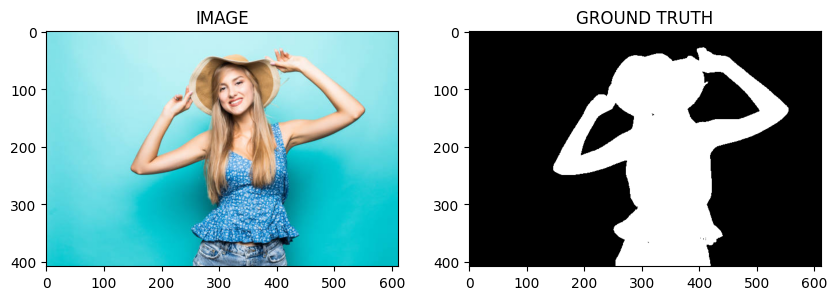

In [11]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.set_title('IMAGE')
ax1.imshow(image)

ax2.set_title('GROUND TRUTH')
ax2.imshow(mask,cmap = 'gray')
plt.show()

In [12]:
train_df, valid_df = train_test_split(df,test_size = 0.2, random_state = 42)

# Augmetation functions
* albumentation documentation : https://albumentations.ai/docs/

In [13]:
import albumentations as A

In [14]:
def get_train_augs():
  return A.Compose([
      A.Resize(IMAGE_SIZE, IMAGE_SIZE),
      A.HorizontalFlip(p = 0.5),
      A.VerticalFlip(p = 0.5)
  ], is_check_shapes=False)

def get_valid_augs():
  return A.Compose([
      A.Resize(IMAGE_SIZE, IMAGE_SIZE),
  ], is_check_shapes=False)

# Create Custom Dataset

In [15]:
class SegmentationDataset(Dataset):
  def __init__(self, df, augmentations):
    self.df = df
    self.augmentations = augmentations

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    image_path = row.images
    mask_path = row.masks

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


    mask = cv2.imread(mask_path, 0 )

    mask = np.expand_dims(mask, axis =-1)


    if self.augmentations:
      data = self.augmentations(image = image, mask = mask)
      image = data['image']
      mask = data['mask']

    image = np.transpose(image, (2,0,1)).astype(np.float32)
    mask = np.transpose(mask, (2,0,1)).astype(np.float32)
    image = torch.Tensor(image) / 255.0
    mask = torch.round(torch.Tensor(mask) / 255.0)

    return image, mask

In [16]:
trainset = SegmentationDataset(train_df, get_train_augs())
validset = SegmentationDataset(valid_df, get_valid_augs())

In [17]:
print(train_df.iloc[32].masks)
print(train_df.iloc[32].images)
image = cv2.imread(train_df.iloc[32].masks)
mask = cv2.imread(train_df.iloc[32].images)
print(image.shape,mask.shape)

Human-Segmentation-Dataset-master/Ground_Truth/42.png
Human-Segmentation-Dataset-master/Training_Images/42.jpg
(169, 299, 3) (169, 299, 3)


In [18]:
!wget https://raw.githubusercontent.com/udacity/deep-learning-v2-pytorch/3bd7dea850e936d8cb44adda8200e4e2b5d627e3/intro-to-pytorch/helper.py

--2025-11-07 12:49:31--  https://raw.githubusercontent.com/udacity/deep-learning-v2-pytorch/3bd7dea850e936d8cb44adda8200e4e2b5d627e3/intro-to-pytorch/helper.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2813 (2.7K) [text/plain]
Saving to: ‘helper.py’

helper.py           100%[===================>]   2.75K  --.-KB/s    in 0s      

2025-11-07 12:49:32 (49.3 MB/s) - ‘helper.py’ saved [2813/2813]



In [19]:
!wget -c https://raw.githubusercontent.com/udacity/deep-learning-v2-pytorch/master/intro-to-pytorch/helper.py

--2025-11-07 12:49:32--  https://raw.githubusercontent.com/udacity/deep-learning-v2-pytorch/master/intro-to-pytorch/helper.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 416 Range Not Satisfiable

    The file is already fully retrieved; nothing to do.



In [20]:
idx = 32
image, mask = trainset[idx]

# Load dataset into batches

In [21]:
from torch.utils.data import DataLoader

In [22]:
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE,shuffle=True)
validloader = DataLoader(validset, batch_size=BATCH_SIZE)
print(f"Size of Trainset : {len(trainset)}")
print(f"Size of Validset : {len(validset)}")
for image, mask in trainloader:
  break

print(f"One batch image shape : {image.shape}")
print(f"One batch mask shape : {mask.shape}")

Size of Trainset : 232
Size of Validset : 58
One batch image shape : torch.Size([8, 3, 224, 224])
One batch mask shape : torch.Size([8, 1, 224, 224])


# Prepare model

In [23]:
class conv_block(nn.Module):
  def __init__(self, in_c, out_c):
    super().__init__()
    self.conv1 = nn.Conv2d(in_c, out_c, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm2d(out_c)
    self.conv2 = nn.Conv2d(out_c, out_c, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(out_c)
    self.relu = nn.ReLU()
  def forward(self, inputs):
    x = self.conv1(inputs)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.conv2(x)
    x = self.bn2(x)
    x = self.relu(x)
    return x

class encoder_block(nn.Module):
  def __init__(self, in_c, out_c):
    super().__init__()
    self.conv = conv_block(in_c, out_c)
    self.pool = nn.MaxPool2d((2, 2))
  def forward(self, inputs):
    x = self.conv(inputs)
    p = self.pool(x)
    return x, p

class decoder_block(nn.Module):
  def __init__(self, in_c, out_c):
    super().__init__()
    self.up = nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2, padding=0)
    self.conv = conv_block(out_c+out_c, out_c)
  def forward(self, inputs, skip):
    x = self.up(inputs)
    x = torch.cat([x, skip], axis=1)
    x = self.conv(x)
    return x

In [24]:
print((2*2*128+1)*64)

32832


In [25]:
class build_unet(nn.Module):
  def __init__(self):
    super().__init__()
    """ Encoder """
    self.e1 = encoder_block(3, 64)
    self.e2 = encoder_block(64, 128)
    self.e3 = encoder_block(128, 256)
    self.e4 = encoder_block(256, 512)
    """ Bottleneck """
    self.b = conv_block(512, 1024)
    """ Decoder """
    self.d1 = decoder_block(1024, 512)
    self.d2 = decoder_block(512, 256)
    self.d3 = decoder_block(256, 128)
    self.d4 = decoder_block(128, 64)
    """ Classifier """
    self.outputs = nn.Conv2d(64, 1, kernel_size=1, padding=0)
  def forward(self, inputs):
    """ Encoder """
    s1, p1 = self.e1(inputs)
    s2, p2 = self.e2(p1)
    s3, p3 = self.e3(p2)
    s4, p4 = self.e4(p3)
    """ Bottleneck """
    b = self.b(p4)
    """ Decoder """
    d1 = self.d1(b, s4)
    d2 = self.d2(d1, s3)
    d3 = self.d3(d2, s2)
    d4 = self.d4(d3, s1)
    """ Classifier """
    outputs = self.outputs(d4)
    return outputs

In [26]:
class SegmentationModel(nn.Module):
  def __init__(self):
    super(SegmentationModel,self).__init__()

    self.arc = build_unet()

  def forward(self, images, masks = None):
    logits = self.arc(images)

    if masks != None:
      loss1 = DiceLoss(mode="binary")(logits,masks)
      loss2 = nn.BCEWithLogitsLoss()(logits,masks)
      return logits, loss1 + loss2

    return logits

In [27]:
DEVICE = 'cuda'

model = SegmentationModel()
model.to(DEVICE)



SegmentationModel(
  (arc): build_unet(
    (e1): encoder_block(
      (conv): conv_block(
        (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
      )
      (pool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    )
    (e2): encoder_block(
      (conv): conv_block(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      

In [28]:
from torchsummary import summary

summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
       BatchNorm2d-2         [-1, 64, 224, 224]             128
              ReLU-3         [-1, 64, 224, 224]               0
            Conv2d-4         [-1, 64, 224, 224]          36,928
       BatchNorm2d-5         [-1, 64, 224, 224]             128
              ReLU-6         [-1, 64, 224, 224]               0
        conv_block-7         [-1, 64, 224, 224]               0
         MaxPool2d-8         [-1, 64, 112, 112]               0
     encoder_block-9  [[-1, 64, 224, 224], [-1, 64, 112, 112]]               0
           Conv2d-10        [-1, 128, 112, 112]          73,856
      BatchNorm2d-11        [-1, 128, 112, 112]             256
             ReLU-12        [-1, 128, 112, 112]               0
           Conv2d-13        [-1, 128, 112, 112]         147,584
      BatchNorm2d-14    

# Create Train and Validation Function

In [29]:
def train_fn(data_loader, model, optimizer):
  model.train()
  total_loss = 0.0
  for images, masks in tqdm(data_loader):
    images = images.to(DEVICE)
    masks = masks.to(DEVICE)

    optimizer.zero_grad()
    ligits, loss = model(images, masks)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()


  return total_loss / len(data_loader)


def eval_fn(data_loader, model):
  model.eval()
  total_loss = 0.0

  with torch.no_grad():

    for images, masks in tqdm(data_loader):
      images = images.to(DEVICE)
      masks = masks.to(DEVICE)


      ligits, loss = model(images, masks)


      total_loss += loss.item()
  return total_loss / len(data_loader)




# Train the model

In [30]:
optimizer = torch.optim.Adam(model.parameters(), lr = LR)

In [31]:
best_valid_loss = np.inf

for i in range(EPOCHS):
  train_loss = train_fn(trainloader, model, optimizer)
  valid_loss = eval_fn(validloader, model)
  print('train_loss',train_loss,'valid_loss',valid_loss)

  if valid_loss < best_valid_loss:
    torch.save(model.state_dict(), 'best_model.pt')
    print('saved model')
    best_valid_loss = valid_loss

  print(f"Epoch : {i+1} Train_loss : {train_loss} Valid_loss : {valid_loss}")

100%|██████████| 8/8 [00:01<00:00,  6.75it/s]


train_loss 1.1922654941164215 valid_loss 6.547946989536285
saved model
Epoch : 1 Train_loss : 1.1922654941164215 Valid_loss : 6.547946989536285


100%|██████████| 8/8 [00:01<00:00,  6.78it/s]


train_loss 1.0047046028334519 valid_loss 1.1885646805167198
saved model
Epoch : 2 Train_loss : 1.0047046028334519 Valid_loss : 1.1885646805167198


100%|██████████| 8/8 [00:01<00:00,  6.68it/s]


...

train_loss 0.6896464310843369 valid_loss 0.7454807311296463
Epoch : 23 Train_loss : 0.6896464310843369 Valid_loss : 0.7454807311296463


100%|██████████| 8/8 [00:01<00:00,  6.44it/s]


train_loss 0.6913975682751886 valid_loss 0.6778563186526299
Epoch : 24 Train_loss : 0.6913975682751886 Valid_loss : 0.6778563186526299


100%|██████████| 8/8 [00:01<00:00,  6.46it/s]

train_loss 0.692500324084841 valid_loss 0.7007463350892067
Epoch : 25 Train_loss : 0.692500324084841 Valid_loss : 0.7007463350892067


# Inference

In [32]:
idx = 20
model.load_state_dict(torch.load('/content/best_model.pt'))
image, mask = validset[idx]

logits_mask = model(image.to(DEVICE).unsqueeze(0))
pred_mask = torch.sigmoid(logits_mask)
pred_mask = (pred_mask > 0.5) * 1.0

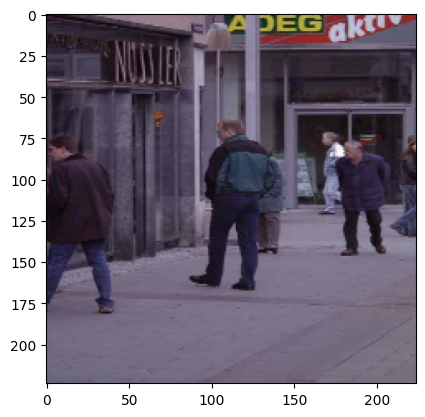

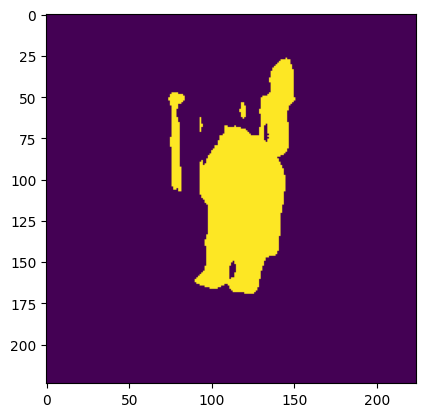

In [33]:
# helper.show_image(image,mask,pred_mask.detach().cpu().squeeze(0))
plt.imshow(image.permute((1,2,0)));plt.show()
plt.imshow(pred_mask.detach().cpu().squeeze(0).permute((1,2,0)));plt.show()

# Evaluation

In [34]:
SMOOTH = 1e-6
def iou_score(pred_masks, masks):
    # You can comment out this line if you are passing tensors of equal shape
    # But if you are passing output from UNet or something it will most probably
    # be with the BATCH x 1 x H x W shape
    pred_masks = pred_masks.squeeze(1)  # BATCH x 1 x H x W => BATCH x H x W
    masks = masks.squeeze(1)  # BATCH x 1 x H x W => BATCH x H x W

    intersection = (pred_masks & masks).float().sum((1,2))  # Will be zero if Truth=0 or Prediction=0
    union = (pred_masks | masks).float().sum((1,2))         # Will be zzero if both are 0

    iou = (intersection + SMOOTH) / (union + SMOOTH)  # We smooth our devision to avoid 0/0

    return iou  # Or iou.mean() if you are interested in average across the batch


model.load_state_dict(torch.load('/content/best_model.pt'))
n = 0
iou = 0
for images, masks in validloader:
  logits_mask = model(images.to(DEVICE))
  pred_masks = torch.sigmoid(logits_mask)
  pred_masks = (pred_masks > 0.5) * 1
  n += images.shape[0]
  iou += iou_score(pred_masks.type(torch.int64) ,masks.type(torch.int64).to(DEVICE)).sum()


print('mIoU = ',iou/n)


mIoU =  tensor(0.5568, device='cuda:0')
